# Climate Resilience

Visualize sm anomalies to start with

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import seaborn as sns

# to pick it up fast where you left
sm_df = pd.read_csv(os.path.join('Data/soil_moisture','Soil_moisture.csv'), index_col=0, header=0)
sm_df.index = pd.to_datetime(sm_df.index)

print(sm_df.head())

                           sm  DOY  rolling_mean    sm_DOY  sm anomaly
time                                                                  
2013-01-01 12:00:00  0.382101    1      0.382101  0.386472   -0.004372
2013-01-02 12:00:00  0.385550    2      0.383825  0.402181   -0.018355
2013-01-03 12:00:00  0.394981    3      0.387544  0.391092   -0.003548
2013-01-04 12:00:00  0.415513    4      0.394536  0.394959   -0.000423
2013-01-05 12:00:00  0.375339    5      0.390697  0.371329    0.019367


<Figure size 200x2000 with 0 Axes>

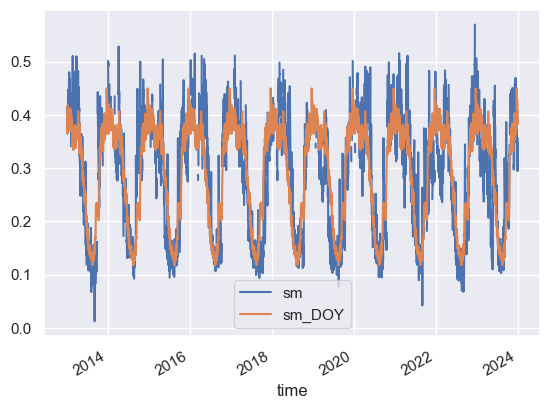

In [4]:
plt.close()
sns.set_theme()

plt.figure(figsize=(2,20))
sm_df[['sm','sm_DOY']].plot()
plt.savefig('soilmoistureALL.png', dpi=500)

plt.show()

C:\Users\ici-1\AppData\Local\Temp\ipykernel_18880\3249185491.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('bwr')  # blue-white-red


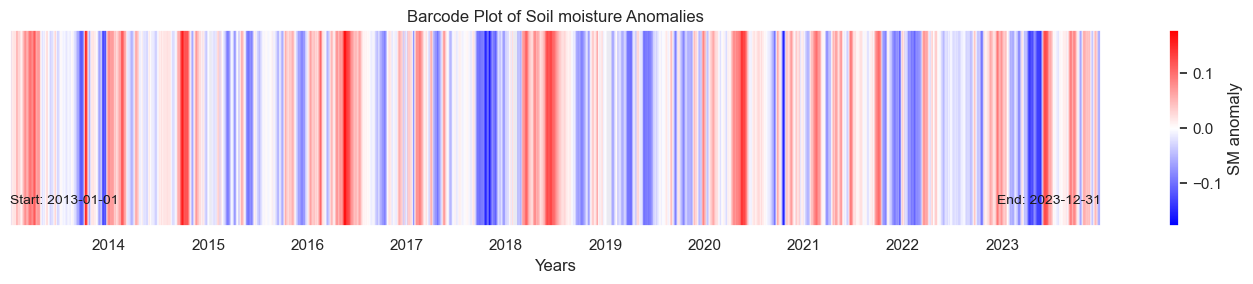

In [5]:
# Create a beautfiul plot with the downloaded data (heatmap?)
# Inspiration: https://showyourstripes.info/c/europe/portugal/lisbon
# How do I want to visualize this?

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm



# Prepare color mapping: red (-), white (0), blue (+)
norm = Normalize(vmin=sm_df['sm anomaly'].min(), vmax=sm_df['sm anomaly'].max())
cmap = cm.get_cmap('bwr')  # blue-white-red


fig, ax = plt.subplots(figsize=(14, 3))

# Create barcode plot
for i in sm_df.index:
    score = sm_df['sm anomaly'][i]
    ax.axvline(x=i, color=cmap(norm(score)), linewidth=1)


# Add start and end markers
start_label = f"Start: {sm_df.index[0].date()}"
end_label = f"End: {sm_df.index[-1].date()}"
ax.text(sm_df.index[0], 0.1, start_label, ha='left', va='bottom', fontsize=10, color='k', transform=ax.get_xaxis_transform())
ax.text(sm_df.index[-1], 0.1, end_label, ha='right', va='bottom', fontsize=10, color='k', transform=ax.get_xaxis_transform())


plt.title('Barcode Plot of Soil moisture Anomalies')
plt.yticks([])
plt.xlabel('Years')
plt.xlim(sm_df.index[0], sm_df.index[-1])


# Add colorbar with mappable
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # needed for colorbar
fig.colorbar(sm, ax=ax, orientation='vertical', label='SM anomaly')

plt.tight_layout()
plt.show()


check

There is a lot more that you can do with outputs (such as including interactive outputs)
with your book. For more information about this, see [the Jupyter Book documentation](https://jupyterbook.org)